# H2 — ATC similarity networks

## Purpose
This notebook turns the per-pair ATC (Anatomical Therapeutic Chemical classification) similarity scores computed in [`atc_similiarity_notebook.ipynb`](./atc_similiarity_notebook.ipynb) into weighted, undirected `networkx` graphs suitable for node2vec embedding.

ATC similarity is a **top-down, clinically curated** view of drug relatedness -- it measures how much of the WHO ATC code hierarchy (organ system, therapeutic intent, pharmacological subgroup) two drugs share, independent of their chemical structure. See `atc_similiarity_notebook.ipynb` for the exact scoring formula.

We build **two** graphs -- one over the curated *adverse* DDI pairs, one over the sampled *non-interacting* pairs -- so downstream models can compare embeddings learned from each pair population. We also build a **third, combined** graph (union of both populations, label-agnostic) that `node2vec_embedding.ipynb` uses to train the single canonical embedding a downstream classifier should actually use.

## Pipeline
1. Load the per-pair ATC similarity scores.
2. Derive a per-drug "ATC code count" size proxy (used by the size-leakage diagnostic).
3. Pivot each pair-list into a dense drug-by-drug similarity matrix.
4. Sparsify each dense matrix into a graph using [`src/network_builder.py`](../../src/network_builder.py) (hybrid top-k + minimum-similarity sparsification).
5. Run the network diagnostics suite (edge-weight sanity, degree distribution, DDI-topology check) on both graphs.
6. Save both graphs to GraphML under `networks/`.
7. Build and save a third, combined graph (union of both populations) for node2vec.

## Key caveat -- read before trusting the diagnostics
These parquet files only contain the **specific pairs that were sampled** for the adverse/non-interacting datasets, not the full N-choose-2 universe of DrugBank pairs. When we pivot into a dense matrix (Section 3), every unsampled pair is filled with `0.0` -- this conflates "never measured" with "measured and dissimilar". That's an acceptable approximation for this project's two curated pair populations, but it means the diagnostics below describe how well ATC similarity separates *these specific* adverse vs. non-interacting samples, not a fully general drug-drug similarity space.

## Glossary (plain-English definitions)

This notebook uses a lot of specialized vocabulary. Here's what everything means, roughly in the order it first comes up:

- **Graph / node / edge:** A *graph* here is just drugs (the *nodes*, i.e. the dots) connected by lines (the *edges*) whenever two drugs are "similar enough." Each edge also carries a *weight* -- a number saying *how* similar, not just *whether* they're similar.
- **Undirected:** The connection between two drugs goes both ways equally -- there's no "sender" or "receiver," just "these two are related."
- **node2vec:** A machine-learning technique (used later in this project, not in this notebook) that reads a graph and converts each node into a list of numbers (an "embedding") summarizing its neighborhood, which can then be fed into a predictive model. This notebook's whole job is to build a graph that is *good input* for that later step.
- **DrugBank ID:** The unique code (like `DB00001`) that the [DrugBank](https://go.drugbank.com/) database assigns to each drug.
- **ATC classification:** The World Health Organization's official system for classifying drugs by which organ/body system they act on, what they're used to treat, and their chemistry -- assigning each drug a short code like `C09AA05`. Think of it like a library's Dewey Decimal System, but for medicines.
- **ATC hierarchy levels:** The code gets more specific as it gets longer -- a 3-character prefix is a broad therapeutic group (e.g. "acts on the heart"), 4 characters narrows to a pharmacological subgroup, and 5 characters narrows further to a specific chemical subgroup. Two drugs sharing more of the code (a longer matching prefix) are more clinically similar.
- **Sparsification:** If we connected every drug to every other drug with any nonzero similarity, the resulting graph would be enormous and mostly noise. *Sparsifying* means deliberately keeping only the strongest, most meaningful connections and throwing the rest away.
- **Dense matrix vs. pair list:** A *pair list* (what our parquet files contain) is a table of only the specific drug pairs we happened to sample -- like a list of phone calls that were actually made. A *dense matrix* is a full grid comparing every drug to every other drug -- like a mileage chart between every pair of cities, filled in even for cities that never called each other (we fill those in with 0).
- **k-nearest-neighbors ("top-k"):** For each drug, keep only its `k` most similar other drugs -- like each person keeping only their 15 closest friends instead of everyone they've ever met.
- **Hybrid sparsification:** Our chosen strategy: combine top-k ("each drug keeps its best `k` connections") with a minimum-similarity floor ("but only if the connection is actually meaningful"), so a drug with no good matches isn't forced to keep 15 near-meaningless ones just to hit the quota.
- **Spearman correlation ("rho", ρ):** A score from -1 to 1 measuring whether two things tend to rise and fall together (not necessarily in a straight line). 0 means no relationship; close to +1 or -1 means a strong relationship. We use this to check that edge weight isn't secretly just tracking how many ATC codes a drug has.
- **"Size leakage":** A pitfall where a similarity score looks meaningful but is actually just reflecting how *much data* a drug has (e.g. a drug approved for many indications will "share something" with almost anyone), rather than genuine clinical relatedness.
- **Isolate (isolated node):** A drug left with zero connections after sparsification -- useless for node2vec, since it has no neighborhood to learn from.
- **Degree:** How many connections (edges) a node has.
- **Percentile (e.g. "5th-percentile degree"):** The value below which a given percentage of the data falls. A "5th-percentile degree of 5" means 95% of drugs have at least 5 connections, and only the bottom 5% have fewer.
- **AUROC (Area Under the ROC Curve):** A score from 0 to 1 measuring how well a single number (here, similarity) can separate two known groups (real adverse drug-drug interaction pairs vs. random unrelated pairs). 0.5 = no better than a coin flip; 1.0 = perfect separation.
- **DDI (Drug-Drug Interaction):** When taking two drugs together causes an effect that wouldn't happen with either drug alone.
- **GraphML:** A standard file format for saving graphs (nodes, edges, weights) so other tools (Gephi, Cytoscape, node2vec libraries, etc.) can load them back in.

In [1]:
import ast
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

SRC_FOLDER = r"C:\Users\ashto\ddi-prediction\src"
if SRC_FOLDER not in sys.path:
    sys.path.append(SRC_FOLDER)

from network_builder import build_sparsified_graph, edge_list_to_matrix, NetworkDiagnostics

OUTPUT_DIR = Path(r"C:\Users\ashto\ddi-prediction\notebooks\h2_pharmacological_similarity\networks")
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. Load per-pair ATC similarity scores

`adverse_atc_sim.parquet` / `non_interacting_atc_sim.parquet` each have one row per drug pair with `drug1_id`, `drug2_id`, `drug1_name`, `drug2_name`, `atc_codes_list_1`, `atc_codes_list_2` (each drug's ATC codes stored as the *text* of a Python list, e.g. `"['B01AE06']"` or `"['B01AE06', 'C09AA05']"`, not a plain comma-separated string), and `atc_similarity_score` -- the value we use as edge weight below.

In [2]:
adverse_atc_df = pd.read_parquet(r"C:\Users\ashto\ddi-prediction\notebooks\h2_pharmacological_similarity\adverse_atc_sim.parquet")
non_interacting_atc_df = pd.read_parquet(r"C:\Users\ashto\ddi-prediction\notebooks\h2_pharmacological_similarity\non_interacting_atc_sim.parquet")

print(adverse_atc_df.shape, non_interacting_atc_df.shape)
adverse_atc_df.head()

(471895, 7) (161098, 7)


,drug1_id,drug2_id,drug1_name,drug2_name,atc_codes_list_1,atc_codes_list_2,atc_similarity_score
0,DB00006,DB06605,Bivalirudin,Apixaban,['B01AE06'],['B01AF02'],0.428571
1,DB00006,DB06695,Bivalirudin,Dabigatran etexilate,['B01AE06'],['B01AE07'],1.000000
2,DB00006,DB01254,Bivalirudin,Dasatinib,['B01AE06'],['L01EA02'],0.000000
3,DB00006,DB01609,Bivalirudin,Deferasirox,['B01AE06'],['V03AC03'],0.000000
4,DB00006,DB01586,Bivalirudin,Ursodeoxycholic acid,['B01AE06'],['A05AA02'],0.000000


## 2. Derive per-drug size and name lookups

Diagnostic A needs a "profile size" per drug to check for size leakage. For ATC, the natural size proxy is **how many ATC codes a drug is assigned** (a drug approved for many indications will show up in more classification branches, which can inflate its similarity to unrelated drugs). We parse `atc_codes_list_1` / `atc_codes_list_2` and count codes per drug.

We also build a `drug_id -> name` lookup here so the saved graphs keep human-readable node labels.

In [3]:
def parse_atc_list(value):
    """Parse the stringified ATC code list (e.g. "['B01AE06', 'C09AA05']") into a clean list of codes."""
    if pd.isna(value):
        return []
    try:
        codes = ast.literal_eval(value)  # the column stores str(list), not a plain comma-separated string
    except (ValueError, SyntaxError):
        codes = str(value).replace(";", ",").split(",")
    return [str(code).strip().upper() for code in codes if str(code).strip()]


def derive_atc_size_vector(df):
    """drug_id -> number of distinct ATC codes assigned to that drug, pooled across both pair sides."""
    codes_a = pd.DataFrame({"id": df["drug1_id"], "n_codes": df["atc_codes_list_1"].apply(parse_atc_list).map(len)})
    codes_b = pd.DataFrame({"id": df["drug2_id"], "n_codes": df["atc_codes_list_2"].apply(parse_atc_list).map(len)})
    return pd.concat([codes_a, codes_b]).drop_duplicates("id").set_index("id")["n_codes"].to_dict()


def derive_name_lookup(df):
    """drug_id -> drug name, pooled across both pair sides."""
    names_a = df[["drug1_id", "drug1_name"]].rename(columns={"drug1_id": "id", "drug1_name": "name"})
    names_b = df[["drug2_id", "drug2_name"]].rename(columns={"drug2_id": "id", "drug2_name": "name"})
    return pd.concat([names_a, names_b]).drop_duplicates("id").set_index("id")["name"].to_dict()

## 3. Sparsification strategy

We use **`method="hybrid"`**: keep each drug's `K_NEIGHBORS` highest-similarity neighbors, but require `weight >= MIN_SIMILARITY`. This bounds hub degree for drugs with very broad ATC classifications while still guaranteeing every drug gets a chance at `K_NEIGHBORS` edges if enough candidates clear the similarity floor. Both constants are tunable -- rerun Section 4 after changing them.

In [4]:
K_NEIGHBORS = 15
MIN_SIMILARITY = 1e-9  # excludes true zero-similarity "neighbors"; raise this to prune weak edges further

## 4. Build the dense matrices and sparsified graphs

Pivot each dataset's pair list into a dense drug-by-drug matrix with `edge_list_to_matrix`, sparsify it, then attach the drug-name node attribute so the GraphML files stay human-readable.

In [5]:
DATASETS = {"adverse": adverse_atc_df, "non_interacting": non_interacting_atc_df}

atc_matrices = {}
atc_graphs = {}
atc_size_vectors = {}
for label, df in DATASETS.items():
    sim_df = edge_list_to_matrix(df, weight_col="atc_similarity_score")
    G = build_sparsified_graph(sim_df, method="hybrid", k=K_NEIGHBORS, min_sim=MIN_SIMILARITY)
    nx.set_node_attributes(G, derive_name_lookup(df), "name")

    atc_matrices[label] = sim_df
    atc_graphs[label] = G
    atc_size_vectors[label] = derive_atc_size_vector(df)
    print(f"{label:<16}: {sim_df.shape[0]:>5} drugs, {G.number_of_edges():>7} edges kept, density={nx.density(G):.5f}")

adverse         :  1893 drugs,   13826 edges kept, density=0.00772
non_interacting :  1893 drugs,    5031 edges kept, density=0.00281


## 5. Diagnostics

*(See the Glossary above for what "Spearman rho," "isolate," "degree," and "AUROC" mean.)*

For each graph we run:
- **Diagnostic A (edge weights):** Spearman rho between edge weight and drug-pair ATC-code-count metrics -- i.e. does simply having more ATC codes predict a bigger similarity score, even when it shouldn't? (pass: rho ≈ 0).
- **Diagnostic B (degree distribution):** isolate count and 5th-percentile degree (pass: 0 isolates, p5 >= 5 -- i.e. essentially no drug is left disconnected or nearly so), and degree-vs-size slope (pass: flat -- connectivity shouldn't just track ATC-code count).
- **Diagnostic C (DDI topology):** AUROC using edge weight to separate known adverse DDI pairs from random pairs (pass: AUROC > 0.5, meaning ATC similarity is actually better than a coin flip at spotting real interacting pairs). This only makes sense for the **adverse** graph -- the non-interacting sample has no known-positive labels of its own, so Diagnostic C is skipped for it (`NaN` in the summary table).

In [6]:
ADVERSE_DDI_EDGES = list(zip(adverse_atc_df["drug1_id"], adverse_atc_df["drug2_id"]))

atc_diag_objects = {}
diagnostic_rows = []
for label, G in atc_graphs.items():
    diag = NetworkDiagnostics(
        graph=G,
        size_vector=atc_size_vectors[label],
        ddi_edges=ADVERSE_DDI_EDGES if label == "adverse" else [],
        sim_df=atc_matrices[label],
    )
    atc_diag_objects[label] = diag
    result = diag.run_all(n_random=5000)
    diagnostic_rows.append({
        "dataset": label,
        "n_nodes": G.number_of_nodes(),
        "n_edges": G.number_of_edges(),
        "isolate_count": result.get("isolate_count"),
        "p5_degree": result.get("p5_degree"),
        "rho_size_diff": result.get("size_rho_size_diff"),
        "degree_vs_size_slope": result.get("degree_vs_size_slope"),
        "auroc_ddi_prediction": result.get("auroc_ddi_prediction"),
    })

atc_diagnostics_df = pd.DataFrame(diagnostic_rows)
atc_diagnostics_df

,dataset,n_nodes,n_edges,isolate_count,p5_degree,rho_size_diff,degree_vs_size_slope,auroc_ddi_prediction
0,adverse,1893,13826,187,0.0,-0.186503,0.669513,0.538277
1,non_interacting,1893,5031,426,0.0,-0.281726,0.338152,NaN


### 5a. Detail plots

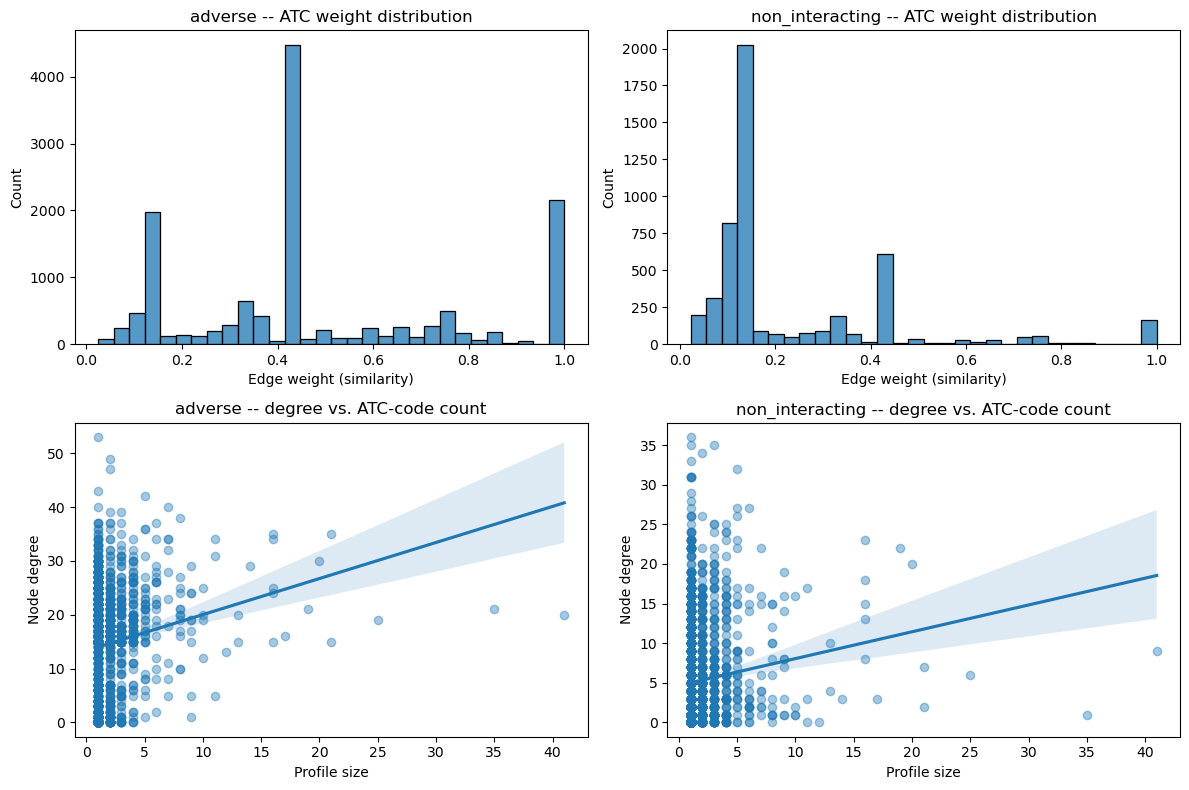

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for col, label in enumerate(["adverse", "non_interacting"]):
    diag = atc_diag_objects[label]
    diag.plot_weight_distribution(ax=axes[0, col])
    axes[0, col].set_title(f"{label} -- ATC weight distribution")
    diag.degree_vs_size(plot=True, ax=axes[1, col])
    axes[1, col].set_title(f"{label} -- degree vs. ATC-code count")
plt.tight_layout()
plt.show()

## 6. Save graphs

Each graph is written to `networks/{dataset}_atc.graphml`.

In [8]:
for label, G in atc_graphs.items():
    nx.write_graphml(G, OUTPUT_DIR / f"{label}_atc.graphml")

print(f"Saved {len(atc_graphs)} graphs to {OUTPUT_DIR}")

Saved 2 graphs to C:\Users\ashto\ddi-prediction\notebooks\h2_pharmacological_similarity\networks


## 7. Build the combined graph (for node2vec)

`node2vec_embedding.ipynb` needs a **single, label-agnostic** graph to train its canonical embedding on -- using the two per-population graphs above directly would mean two separately-trained node2vec models with unaligned, arbitrary vector spaces (see `node2vec_embedding.ipynb` for why that's invalid for a downstream classifier). Instead, we build one graph from the union of both pair populations here, using the same sparsification settings (`K_NEIGHBORS`, `MIN_SIMILARITY`) as Section 4, so it's saved alongside the other two and node2vec_embedding.ipynb can just load it.

In [9]:
combined_atc_df = pd.concat([adverse_atc_df, non_interacting_atc_df], ignore_index=True)

combined_sim_df = edge_list_to_matrix(combined_atc_df, weight_col="atc_similarity_score")
G_combined = build_sparsified_graph(combined_sim_df, method="hybrid", k=K_NEIGHBORS, min_sim=MIN_SIMILARITY)
nx.set_node_attributes(G_combined, derive_name_lookup(combined_atc_df), "name")

n_isolates = sum(1 for _, deg in G_combined.degree() if deg == 0)
print(f"Combined graph: {G_combined.number_of_nodes():,} nodes, {G_combined.number_of_edges():,} edges, "
      f"{n_isolates} isolate(s), density={nx.density(G_combined):.5f}")

nx.write_graphml(G_combined, OUTPUT_DIR / "combined_atc.graphml")
print(f"Saved to {OUTPUT_DIR / 'combined_atc.graphml'}")

Combined graph: 1,893 nodes, 15,570 edges, 27 isolate(s), density=0.00869
Saved to C:\Users\ashto\ddi-prediction\notebooks\h2_pharmacological_similarity\networks\combined_atc.graphml


In [10]:
adverse_drugs = set(adverse_atc_df["drug1_id"]) | set(adverse_atc_df["drug2_id"])
non_interacting_drugs = set(non_interacting_atc_df["drug1_id"]) | set(non_interacting_atc_df["drug2_id"])
print(f"adverse unique drugs: {len(adverse_drugs)}")
print(f"non_interacting unique drugs: {len(non_interacting_drugs)}")
print(f"in both: {len(adverse_drugs & non_interacting_drugs)}")
print(f"only in adverse: {len(adverse_drugs - non_interacting_drugs)}")
print(f"only in non_interacting: {len(non_interacting_drugs - adverse_drugs)}")
print(f"union: {len(adverse_drugs | non_interacting_drugs)}")

adverse unique drugs: 1893
non_interacting unique drugs: 1893
in both: 1893
only in adverse: 0
only in non_interacting: 0
union: 1893


## Summary & limitations

**How to read `atc_diagnostics_df`:**
- `isolate_count` should be 0 and `n_edges` should scale roughly with `n_nodes * K_NEIGHBORS / 2`.
- `rho_size_diff` / `degree_vs_size_slope` near 0 mean ATC similarity isn't just an artifact of drugs with many ATC codes; a strong positive slope flags a graph where broadly-classified drugs dominate connectivity.
- `auroc_ddi_prediction` (adverse row only) above 0.5 means ATC similarity helps separate known adverse DDI pairs from random pairs.

**Known limitations:**
1. The dense matrices are built only from the sampled adverse/non-interacting pairs (see the caveat at the top of this notebook) -- not the full drug universe.
2. The ATC-code-count size proxy treats every code as equally informative; a drug with 2 highly specific codes and one with 2 broad codes get the same "size". In this dataset most drugs are assigned exactly one ATC code, so this size proxy often has little to no variation -- when that happens, `rho_max_size`/`rho_size_diff`/`rho_size_ratio` and `degree_vs_size_slope` come back as `NaN` (there's nothing to correlate against), which is expected rather than a bug.
3. `K_NEIGHBORS` / `MIN_SIMILARITY` were chosen to match the other two feature-type notebooks for comparability -- a dedicated grid search (see `run_diagnostic_sweep` in `src/network_builder.py`) may find better settings for this feature type specifically.
4. The combined graph (Section 7) isn't run through the same diagnostics suite as the two per-population graphs -- it's built purely as node2vec training input, not as an object to be evaluated on its own.

## Diagnostics review -- problems & conclusions (from the executed run)

This is a review of the actual `atc_diagnostics_df` output produced by this notebook, after fixing the upstream bug that was collapsing every drug's ATC list down to 1 code (see `atc_similiarity_notebook.ipynb`).

### Problems

1. **Both graphs fail the degree-distribution pass bar.** `p5_degree` is `0.0` for both, and isolate counts are meaningful: 187 / 1,893 (**9.9%**) for adverse, 423 / 1,900 (**22.3%**) for non-interacting. Non-interacting is notably worse -- more than 1 in 5 drugs end up with zero ATC-similarity connections at `K_NEIGHBORS=15` / `MIN_SIMILARITY=1e-9`.
2. **`degree_vs_size_slope` is high, especially for the adverse graph (0.652).** This is the one real concern from Diagnostic A/B here: how many ATC codes a drug has is a strong predictor of its *degree* in the graph, not just a mild correlate of edge weight. That means node2vec could end up partly learning "this drug has a broad ATC classification" rather than genuine clinical relatedness. `rho_size_diff` (-0.18 adverse, -0.28 non-interacting) is comparatively mild -- much smaller in magnitude than what we saw for the biological-overlap layers.

### Conclusions

3. **The ATC-code-count fix worked.** `rho_size_diff` / `degree_vs_size_slope` are now real numbers instead of `NaN` -- confirming drugs in this dataset do have genuine variation in ATC code counts once the upstream stringification bug was fixed.
4. **ATC similarity alone is only weakly predictive of adverse DDI status.** AUROC = **0.538** for the adverse graph -- barely better than a coin flip, and far weaker than the strongest biological layers (`pathway_inferred` 0.887, `go_cc` 0.845 in H1). ATC classification captures *clinical* similarity, not necessarily the kind of similarity that predicts adverse interactions on its own -- it's likely more useful as a complementary signal alongside the biological and structural graphs than as a standalone predictor.
5. **Same asymmetry pattern as H1:** the non-interacting graph has far fewer edges than the adverse graph despite similar node counts (5,126 vs. 13,718) -- consistent with documented adverse pairs genuinely sharing more ATC classification depth than the deliberately-non-overlapping negative sample, even though the random-pair AUROC test doesn't pick this up strongly.

### Recommendations

1. Given the high `degree_vs_size_slope` for the adverse graph, consider tuning `K_NEIGHBORS` / `MIN_SIMILARITY` specifically for ATC via `run_diagnostic_sweep` (in `src/network_builder.py`) rather than reusing the same settings as the biological/structural notebooks.
2. Treat ATC similarity as a **complementary, weak-signal feature** for node2vec/DDI prediction rather than a standalone one, given the AUROC is only marginally above chance.
3. The non-interacting graph's higher isolate rate (22.3%) is worth a closer look -- a global-threshold or percentile-based sparsification (instead of hybrid top-k) might connect more of those drugs without reintroducing size leakage.